In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from keras.utils import np_utils

seed=10
np.random.seed(seed)

Using TensorFlow backend.


In [2]:
os.getcwd()

'C:\\Users\\40101542\\Desktop\\AIML v2\\Projects'

In [3]:
import h5py
import pandas as pd

In [16]:
#Trying to read the file
#The r signifies that we are trying to open a read only copy of this file for our use
h5f=h5py.File('C:\\Users\\40101542\\Desktop\\AIML v2\\Projects\\SVHN_single_grey1.h5','r')

In [17]:
h5f

<HDF5 file "SVHN_single_grey1.h5" (mode r)>

In [18]:
x_train=h5f["X_train"][:]
y_train1=h5f["y_train"][:]
x_test=h5f["X_test"][:]
y_test1=h5f["y_test"][:]


In [19]:
#These are 42,000 images with a shape of 32X32
x_train.shape

(42000, 32, 32)

In [20]:
#We have 18,000 test images with a shape of 32X32
x_test.shape

(18000, 32, 32)

In [7]:
#Closing the file
h5f.close()

In [8]:
#Checking what are the images that have been obtained by us from the dataset


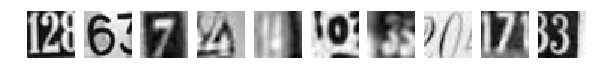

The label is: [2 6 7 4 4 0 3 0 7 3]


In [12]:
#The plt.subplot function is used for getting multiple plots at one place and the loop is for printing the 10 values
%matplotlib inline
plt.figure(figsize=(10,1))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(x_train[i],cmap='gray')
    plt.axis("off")
plt.show()
print("The label is: %s" % (y_train1[0:10]))

In [22]:
#Reshaping the images so that it can be converted into 1-D and can be fed into the Deep Neural Network as it only 
#accepts 1-D vector for classification/Regression

x_train=x_train.reshape(x_train.shape[0],1024)
x_test=x_test.reshape(x_test.shape[0],1024)


In [23]:
#We can now see that we have 42,000 images in this training set with a single D shape of 1024
x_train.shape

(42000, 1024)

In [24]:
x_test.shape

(18000, 1024)

In [25]:
#Normalizing the image data from between 0-255, single channel
x_train=x_train/255.0
x_test=x_test/255.0


In [27]:
#Doing a one hot encoding on the labels of the data

In [28]:
y_train=np_utils.to_categorical(y_train1)
y_test=np_utils.to_categorical(y_test1)

In [30]:
y_train.shape

(42000, 10)

In [34]:
#Number of categories unique:
num_classes=y_train.shape[1]
print(num_classes)

10


In [35]:
num_hidden=32

In [37]:
x_train_new=[]
for i in range(42000):
    x_train_new.append(x_train[i,:].flatten())
x_test_new=[]
for i in range(18000):
    x_test_new.append(x_test[i,:].flatten())


In [49]:
x_train

array([[0.12968785, 0.11866706, 0.10530196, ..., 0.19477727, 0.19942354,
        0.20799099],
       [0.34101608, 0.3414451 , 0.34656274, ..., 0.29498273, 0.30054745,
        0.31092745],
       [0.48284313, 0.49356118, 0.47872823, ..., 0.36837214, 0.41093138,
        0.44637334],
       ...,
       [0.6042902 , 0.61100274, 0.6149663 , ..., 0.52993256, 0.53592   ,
        0.5398412 ],
       [0.8137075 , 0.8176286 , 0.8353796 , ..., 0.83974785, 0.8319055 ,
        0.820142  ],
       [0.37285647, 0.37677765, 0.39246237, ..., 0.5414914 , 0.5509529 ,
        0.5509529 ]], dtype=float32)

In [39]:
x_train_new

[array([0.12968785, 0.11866706, 0.10530196, ..., 0.19477727, 0.19942354,
        0.20799099], dtype=float32),
 array([0.34101608, 0.3414451 , 0.34656274, ..., 0.29498273, 0.30054745,
        0.31092745], dtype=float32),
 array([0.48284313, 0.49356118, 0.47872823, ..., 0.36837214, 0.41093138,
        0.44637334], dtype=float32),
 array([0.5789004, 0.547531 , 0.5592945, ..., 0.6161545, 0.6163902,
        0.6163902], dtype=float32),
 array([0.60387844, 0.6085423 , 0.61736315, ..., 0.17918824, 0.19065568,
        0.22803685], dtype=float32),
 array([0.6343188 , 0.5936992 , 0.43314236, ..., 0.32490197, 0.34086472,
        0.35957646], dtype=float32),
 array([0.4100553 , 0.40730625, 0.3967149 , ..., 0.4580388 , 0.42157608,
        0.4047192 ], dtype=float32),
 array([0.85368663, 0.8497655 , 0.8497655 , ..., 0.84356666, 0.8384733 ,
        0.81924784], dtype=float32),
 array([0.14508353, 0.15382   , 0.16417569, ..., 0.24362667, 0.24982549,
        0.25911805], dtype=float32),
 array([0.208583

In [50]:
x_train_new=x_train_new[:2000]
x_test_new=x_test_new[:2000]
y_train_new=y_train1[0:2000]
y_test_new=y_test1[0:2000]

In [72]:
import scipy
a=[]
j=[]

def knnvalue(k):
    from sklearn.neighbors import KNeighborsClassifier
    NHH = KNeighborsClassifier(n_neighbors=k,weights='distance')
    NHH.fit(x_train_new,y_train_new)
    predicted_labels=NHH.predict(x_test_new)
    from sklearn.metrics import accuracy_score
    accscore=accuracy_score(y_test_new,predicted_labels)
    MSE=1-accscore
    a.append(MSE)
    j.append(k)
    print(accscore)

In [73]:
for i in range(1,30,2):
    knnvalue(i)

0.2975
0.3065
0.3135
0.331
0.331
0.333
0.3235
0.32
0.3135
0.316
0.3185
0.315
0.3125
0.301
0.3


In [75]:
from sklearn.neighbors import KNeighborsClassifier
NHH = KNeighborsClassifier(n_neighbors=11,weights='distance')
NHH.fit(x_train_new,y_train_new)
pred=NHH.predict(x_test_new)

In [76]:
from sklearn.metrics import confusion_matrix
confusion_matrix(pred,y_test_new)

array([[ 81,  10,   4,  16,   9,  20,  23,   3,  27,  33],
       [ 12,  88,  20,  23,  20,  20,  14,  18,  16,  13],
       [ 14,  15,  73,  17,  16,  21,  16,  40,  10,  17],
       [ 10,  10,  17,  38,   9,  14,  14,  26,  19,  14],
       [ 14,  24,  13,   9, 107,  15,  20,  10,  18,  15],
       [ 14,  11,   5,  25,   7,  54,  12,   6,  13,  15],
       [ 30,  11,   6,  14,  16,  21,  65,   9,  36,  19],
       [  7,  10,  23,  18,   6,   6,   7,  82,   5,  15],
       [ 11,   3,   9,   9,   2,  15,  12,   1,  31,  14],
       [ 28,   3,  17,  16,  12,  25,  19,  10,  23,  47]], dtype=int64)

In [77]:
#Accuracy does not seem to be good with KNN classifier so we have to resort to an additional approach for this

In [78]:
from keras.layers import BatchNormalization

In [79]:
#Defining the model
import keras
from keras import losses
from keras import optimizers
from keras.layers import Dropout, MaxPooling2D

In [80]:
def nn_model():
    model=Sequential()
    #The input layer always has the shape of 1024 which is the shape of the input image
    model.add(BatchNormalization(input_shape=(1024,)))
    
    model.add(Dense(256,activation='relu'))
    model.add(Dense(64,activation='relu'))
    model.add(Dense(64,activation='relu'))
    model.add(Dense(32,activation='relu'))
    model.add(Dense(num_classes,activation='softmax'))
    
    #Compiling the created model
    sgd=optimizers.Adam(lr=1e-3)
    model.compile(loss=losses.categorical_crossentropy,optimizer=sgd,metrics=['accuracy'])
    return(model)

In [81]:
#Calling the nn_model function for creating the model
model=nn_model()
model.summary()

W0921 15:54:14.199709 14784 deprecation_wrapper.py:119] From C:\ProgramData\Anaconda3\lib\site-packages\keras\backend\tensorflow_backend.py:74: The name tf.get_default_graph is deprecated. Please use tf.compat.v1.get_default_graph instead.

W0921 15:54:14.331951 14784 deprecation_wrapper.py:119] From C:\ProgramData\Anaconda3\lib\site-packages\keras\backend\tensorflow_backend.py:517: The name tf.placeholder is deprecated. Please use tf.compat.v1.placeholder instead.

W0921 15:54:14.916359 14784 deprecation_wrapper.py:119] From C:\ProgramData\Anaconda3\lib\site-packages\keras\backend\tensorflow_backend.py:133: The name tf.placeholder_with_default is deprecated. Please use tf.compat.v1.placeholder_with_default instead.

W0921 15:54:14.960449 14784 deprecation_wrapper.py:119] From C:\ProgramData\Anaconda3\lib\site-packages\keras\backend\tensorflow_backend.py:4138: The name tf.random_uniform is deprecated. Please use tf.random.uniform instead.

W0921 15:54:15.268281 14784 deprecation_wrappe

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
batch_normalization_1 (Batch (None, 1024)              4096      
_________________________________________________________________
dense_1 (Dense)              (None, 256)               262400    
_________________________________________________________________
dense_2 (Dense)              (None, 64)                16448     
_________________________________________________________________
dense_3 (Dense)              (None, 64)                4160      
_________________________________________________________________
dense_4 (Dense)              (None, 32)                2080      
_________________________________________________________________
dense_5 (Dense)              (None, 10)                330       
Total params: 289,514
Trainable params: 287,466
Non-trainable params: 2,048
_________________________________________________________________


In [82]:
#Fitting the model on the training data

In [84]:
model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=30,batch_size=200,verbose=2)

#Evaluating the model

scores=model.evaluate(x_test,y_test,verbose=0)

#Printing the score
print(scores)


Train on 42000 samples, validate on 18000 samples
Epoch 1/30
 - 4s - loss: 0.4624 - acc: 0.8587 - val_loss: 0.6260 - val_acc: 0.8207
Epoch 2/30
 - 6s - loss: 0.4494 - acc: 0.8611 - val_loss: 0.6375 - val_acc: 0.8179
Epoch 3/30
 - 6s - loss: 0.4340 - acc: 0.8622 - val_loss: 0.6110 - val_acc: 0.8296
Epoch 4/30
 - 6s - loss: 0.4135 - acc: 0.8703 - val_loss: 0.6351 - val_acc: 0.8196
Epoch 5/30
 - 6s - loss: 0.4083 - acc: 0.8724 - val_loss: 0.6209 - val_acc: 0.8279
Epoch 6/30
 - 6s - loss: 0.3913 - acc: 0.8755 - val_loss: 0.6158 - val_acc: 0.8341
Epoch 7/30
 - 6s - loss: 0.3716 - acc: 0.8831 - val_loss: 0.6076 - val_acc: 0.8329
Epoch 8/30
 - 6s - loss: 0.3540 - acc: 0.8882 - val_loss: 0.6255 - val_acc: 0.8296
Epoch 9/30
 - 6s - loss: 0.3581 - acc: 0.8875 - val_loss: 0.6357 - val_acc: 0.8314
Epoch 10/30
 - 5s - loss: 0.3444 - acc: 0.8888 - val_loss: 0.6504 - val_acc: 0.8258
Epoch 11/30
 - 6s - loss: 0.3375 - acc: 0.8945 - val_loss: 0.6114 - val_acc: 0.8376
Epoch 12/30
 - 5s - loss: 0.3262 - 